In [1]:
from dotenv import load_dotenv
load_dotenv() 

True

In [2]:
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from typing import Literal 
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain.agents import create_agent 
from langchain_core.tools import tool 

c:\Users\Dilip Asdeo\miniconda3\envs\genai311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
class FlowState(BaseModel):
    question: str = Field(description="User asked question")
    category: Literal["coding", "google_search", "weather"] = Field(default="google_search")
    answer: str = Field(default="") 

class QuestionCategory(BaseModel):
    category: Literal["coding", "google_search", "weather"] = Field(default="google_search", description="The category of the question")

In [10]:
llm = ChatGroq(model="llama-3.3-70b-versatile") 

In [11]:
# google search agent

search = GoogleSerperAPIWrapper()

google_agent = create_agent(
    model=llm,
    tools = [search.run],
    system_prompt = "You are a helpful assistant and answer questions based on the google search."
)

# weather agent

@tool
def get_weather(city: str):
    """It provides current weather information for a given city."""
    return f"The weather in {city} is sunny with a high of 25 degrees Celsius."

weather_agent = create_agent(
    model=llm,
    tools = [get_weather],
    system_prompt = "You are a helpful assistant that provides weather information based on the city provided in the question."
)



In [14]:
def check_question_category(state: FlowState) -> FlowState:
    st_llm = llm.with_structured_output(QuestionCategory)
    res = st_llm.invoke(f"I want to know the category of the question: {state.question}. The category can be one of the following: coding, google_search, weather. If the question is not related to any of these categories, please choose google_search as the default category.")
    state.category = res.category
    return state 

def route(state: FlowState) -> Literal["coding", "google_search", "weather"]:
    return state.category

def coding_node(state: FlowState) -> FlowState:
    res = llm.invoke(f"You are a coding assistant. Please provide a detailed answer to the following question: {state.question}")
    state.answer = res.content
    return state 

def google_search_node(state: FlowState) -> FlowState:
    res = google_agent.invoke({
        "messages": [{"role": "user", "content": state.question}]
    }) 
    state.answer = res["messages"][-1].content
    return state 

def weather_node(state: FlowState) -> FlowState:
    res = weather_agent.invoke({
        "messages": [{"role": "user", "content": state.question}]
    })
    state.answer = res["messages"][-1].content
    return state

graph = StateGraph(FlowState)

graph.add_node("question_category", check_question_category)
graph.add_node("coding", coding_node)
graph.add_node("google_search", google_search_node)
graph.add_node("weather", weather_node)

graph.add_edge(START, "question_category")
graph.add_conditional_edges("question_category", route)
graph.add_edge("coding", END)
graph.add_edge("google_search", END)
graph.add_edge("weather", END)

graph = graph.compile()

res = graph.invoke({"question": "What is the capital of India?"}) 

res 

{'question': 'What is the capital of India?',
 'category': 'google_search',
 'answer': 'The capital of India is New Delhi.'}

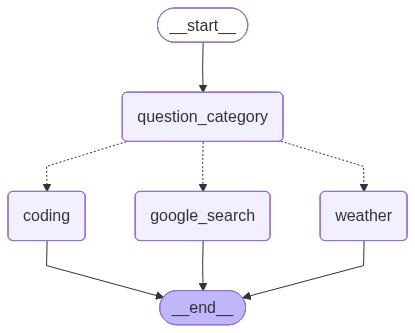

In [7]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png()) 